In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
data=pd.read_csv('tech_mental_health_burnout.csv')

In [6]:
data.shape

(150000, 25)

In [7]:
data.describe()

,age,experience_years,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,seeks_professional_help
count,150000.000000,150000.000000,150000.00000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,38.025340,5.055010,47.00758,6.127180,4.010893,1.284193,5.500248,5.497537,5.016357,6.499120,2.599833,8.002713,2.101693,5.498163,0.251133,5.785428,4.523763,3.096687,2.114121,0.096333
std,9.510609,2.878602,7.89331,3.783618,1.978316,1.426264,1.956102,1.956915,1.948553,1.192343,1.814880,1.987813,1.300247,1.957432,0.433667,1.331506,1.201506,1.187668,1.112614,0.295049
min,22.000000,0.000000,30.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,0.000000,3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,30.000000,3.000000,42.00000,3.000000,3.000000,0.000000,4.200000,4.100000,3.700000,5.700000,1.000000,6.700000,1.000000,4.200000,0.000000,4.900000,3.700000,2.200000,1.000000,0.000000
50%,38.000000,5.000000,47.00000,6.000000,4.000000,1.000000,5.500000,5.500000,5.000000,6.500000,2.000000,8.000000,2.000000,5.500000,0.000000,5.800000,4.500000,3.100000,1.900000,0.000000
75%,46.000000,7.000000,52.00000,9.000000,5.000000,2.000000,6.900000,6.800000,6.400000,7.300000,4.000000,9.300000,3.000000,6.800000,1.000000,6.700000,5.300000,3.900000,2.800000,0.000000
max,54.000000,18.500000,84.00000,24.000000,12.000000,5.000000,10.000000,10.000000,10.000000,10.000000,7.000000,16.000000,5.000000,10.000000,1.000000,10.000000,9.600000,8.100000,8.100000,1.000000


In [8]:
data.isnull().sum()

,0
age,0
gender,0
job_role,0
experience_years,0
company_size,0
work_mode,0
work_hours_per_week,0
overtime_hours,0
meetings_per_day,0
deadlines_missed,0


In [9]:
data.duplicated().any()

np.False_

In [10]:
data.columns

Index(['age', 'gender', 'job_role', 'experience_years', 'company_size',
       'work_mode', 'work_hours_per_week', 'overtime_hours',
       'meetings_per_day', 'deadlines_missed', 'job_satisfaction',
       'manager_support', 'work_life_balance', 'sleep_hours',
       'physical_activity_days', 'screen_time_hours', 'caffeine_intake',
       'social_support_score', 'has_therapy', 'stress_level', 'anxiety_score',
       'depression_score', 'burnout_score', 'burnout_level',
       'seeks_professional_help'],
      dtype='object')

In [11]:
data.dtypes

,0
age,int64
gender,object
job_role,object
experience_years,float64
company_size,object
work_mode,object
work_hours_per_week,float64
overtime_hours,float64
meetings_per_day,float64
deadlines_missed,int64


In [12]:
df=data.copy()

In [13]:
#How do work_hours_per_week and job_satisfaction interact across job roles?

In [14]:
job_roles=df.groupby('job_role')[['work_hours_per_week','job_satisfaction']].agg({'mean','mean'}).reset_index()

In [15]:
df.groupby('job_role').agg({'work_hours_per_week':['mean','max'],'job_satisfaction':'mean'})

work_hours_per_week       job_satisfaction
                                  mean   max             mean
job_role                                                     
Backend Developer            46.879750  84.0         5.479274
Data Scientist               47.043713  77.0         5.507918
DevOps                       47.139827  77.0         5.499020
Frontend Developer           47.105582  77.0         5.523621
ML Engineer                  46.960998  79.0         5.499614
Product Manager              46.951111  78.0         5.475774
QA Engineer                  46.969374  81.0         5.489466
Software Engineer            46.997714  79.0         5.505693

In [16]:
job_roles=job_roles.sort_values(by=('job_satisfaction','mean'))

<Axes: xlabel='job_role'>

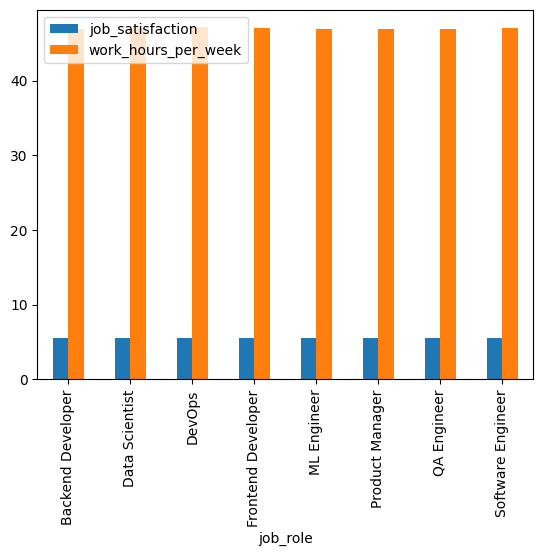

In [17]:
df.pivot_table(index='job_role',values=(['work_hours_per_week','job_satisfaction']),aggfunc='mean').plot(kind='bar')

In [18]:
df['job_role'].unique()

array(['Backend Developer', 'Frontend Developer', 'DevOps',
       'Data Scientist', 'Software Engineer', 'Product Manager',
       'QA Engineer', 'ML Engineer'], dtype=object)

In [19]:
df[df['job_role']=='Backend Developer'][['work_hours_per_week','job_satisfaction']]

,work_hours_per_week,job_satisfaction
0,45.0,5.9
3,57.0,7.0
11,45.0,5.3
14,47.0,3.4
20,56.0,5.1
...,...,...
149973,60.0,8.8
149976,47.0,6.8
149980,48.0,4.4
149983,46.0,7.5


In [20]:
for i in df['job_role'].unique():
    new_df=df[df['job_role']==i][['work_hours_per_week','job_satisfaction']]
    print(f'{i} :- correlation b/w work_hours_per_week and job_satisfaction is {new_df['work_hours_per_week'].corr(new_df['job_satisfaction'])}')

Backend Developer :- correlation b/w work_hours_per_week and job_satisfaction is -0.0071807435736556645
Frontend Developer :- correlation b/w work_hours_per_week and job_satisfaction is -0.008786219933044848
DevOps :- correlation b/w work_hours_per_week and job_satisfaction is 0.011235312118633945
Data Scientist :- correlation b/w work_hours_per_week and job_satisfaction is -0.015124811031484353
Software Engineer :- correlation b/w work_hours_per_week and job_satisfaction is -0.0018018189278459775
Product Manager :- correlation b/w work_hours_per_week and job_satisfaction is -0.005214252585534437
QA Engineer :- correlation b/w work_hours_per_week and job_satisfaction is -0.014926232513109493
ML Engineer :- correlation b/w work_hours_per_week and job_satisfaction is -0.013035258637072014


In [21]:
def job(abc):
    return abc['work_hours_per_week'].corr(abc['job_satisfaction'])

In [22]:
df.groupby('job_role').apply(job)

,0
job_role,
Backend Developer,-0.007181
Data Scientist,-0.015125
DevOps,0.011235
Frontend Developer,-0.008786
ML Engineer,-0.013035
Product Manager,-0.005214
QA Engineer,-0.014926
Software Engineer,-0.001802


In [23]:
#Does meeting load (meetings_per_day) reduce productivity (proxy: deadlines_missed)?

In [24]:
df['meetings_per_day'].corr(df['deadlines_missed'])

np.float64(-0.003956107862557916)

In [25]:
#Which job roles show the highest inefficiency (high hours + low satisfaction)?

In [26]:
highest_inefficiency=df.groupby('job_role')[['work_hours_per_week','job_satisfaction']].mean().reset_index()

In [27]:
highest_inefficiency[(highest_inefficiency['work_hours_per_week']>highest_inefficiency['work_hours_per_week'].mean()) & (highest_inefficiency['job_satisfaction']<highest_inefficiency['job_satisfaction'].mean())]

,job_role,work_hours_per_week,job_satisfaction


In [28]:
#Are employees with fewer deadlines missed always more satisfied?

In [29]:
df['deadlines_missed'].corr(df['job_satisfaction'])

np.float64(-0.004621845812459315)

In [30]:
df['deadlines_missed'].describe()

,deadlines_missed
count,150000.000000
mean,1.284193
std,1.426264
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,5.000000


In [31]:
df.groupby('deadlines_missed')['job_satisfaction'].mean().sort_values(ascending=False)

,job_satisfaction
deadlines_missed,
0,5.511024
2,5.508217
1,5.492346
4,5.491166
3,5.481030
5,5.472871


<Axes: xlabel='deadlines_missed'>

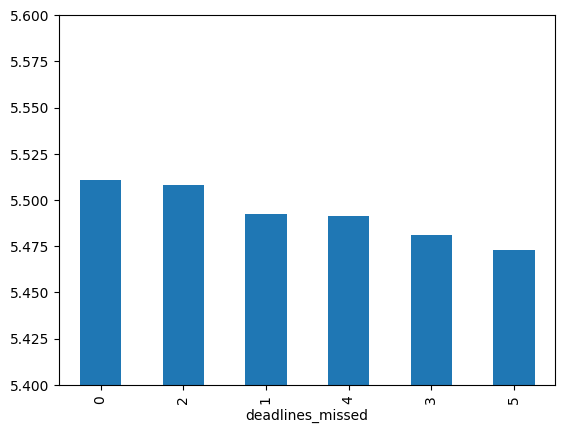

In [32]:
df.groupby('deadlines_missed')['job_satisfaction'].mean().sort_values(ascending=False).plot(kind='bar',ylim=(5.4,5.6))

In [33]:
#work_hours_per_week and job_satisfaction

In [34]:
print(df[df['work_hours_per_week']<df['work_hours_per_week'].quantile(0.25)]['job_satisfaction'].mean())
print(df[(df['work_hours_per_week']<df['work_hours_per_week'].quantile(0.50)) & (df['work_hours_per_week']>df['work_hours_per_week'].quantile(0.25))]['job_satisfaction'].mean())
print(df[(df['work_hours_per_week']>df['work_hours_per_week'].quantile(0.50)) & (df['work_hours_per_week']<df['work_hours_per_week'].quantile(0.75))]['job_satisfaction'].mean())
print(df[df['work_hours_per_week']>df['work_hours_per_week'].quantile(0.75)]['job_satisfaction'].mean())

5.519428417363171
5.49651039080786
5.502356626677584
5.485439921208141


In [35]:
df.groupby(pd.qcut(df['work_hours_per_week'],4,labels=['Q1','Q2','Q3','Q4']))['job_satisfaction'].mean()

,job_satisfaction
work_hours_per_week,
Q1,5.514044
Q2,5.501221
Q3,5.497570
Q4,5.485440


<Axes: xlabel='work_hours_per_week'>

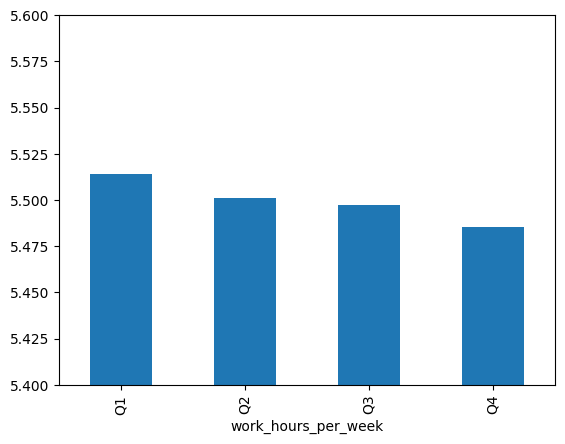

In [36]:
df.groupby(pd.qcut(df['work_hours_per_week'],4,labels=['Q1','Q2','Q3','Q4']))['job_satisfaction'].mean().plot(kind='bar',ylim=(5.4,5.6))

In [37]:
#Which factors contribute most to burnout_score (feature importance)?

In [38]:
df['burnout_score']

,burnout_score
0,1.0
1,3.7
2,1.0
3,3.6
4,3.5
...,...
149995,1.2
149996,1.1
149997,2.8
149998,1.5


In [39]:
from sklearn.ensemble import RandomForestRegressor

In [40]:
rf=RandomForestRegressor()

In [41]:
df.columns

Index(['age', 'gender', 'job_role', 'experience_years', 'company_size',
       'work_mode', 'work_hours_per_week', 'overtime_hours',
       'meetings_per_day', 'deadlines_missed', 'job_satisfaction',
       'manager_support', 'work_life_balance', 'sleep_hours',
       'physical_activity_days', 'screen_time_hours', 'caffeine_intake',
       'social_support_score', 'has_therapy', 'stress_level', 'anxiety_score',
       'depression_score', 'burnout_score', 'burnout_level',
       'seeks_professional_help'],
      dtype='object')

In [42]:
x=df.drop(columns=['burnout_score'])

In [43]:
y=df['burnout_score']

In [44]:
x=pd.get_dummies(x)

In [45]:
x.shape

(150000, 40)

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [48]:
model=rf.fit(x_train,y_train)

In [49]:
pred=model.predict(x_test)

In [50]:
from sklearn.metrics import r2_score

In [51]:
r2_score(y_test,pred)

0.8362121875588415

In [52]:
rf.feature_importances_

array([0.00910496, 0.01062404, 0.04038493, 0.0139832 , 0.00576194,
       0.00386501, 0.01044705, 0.02530489, 0.02542558, 0.01006752,
       0.00495133, 0.01046436, 0.00428977, 0.01037083, 0.01689466,
       0.21934597, 0.02511197, 0.01549258, 0.00140583, 0.00098955,
       0.00102299, 0.0005592 , 0.00089338, 0.00101465, 0.00084527,
       0.00090585, 0.000929  , 0.00078613, 0.00071055, 0.00123898,
       0.00114918, 0.00116088, 0.00113626, 0.00115507, 0.00120552,
       0.00107896, 0.00118182, 0.00080492, 0.51688107, 0.00105432])

In [53]:
feature_imp=pd.Series(rf.feature_importances_,index=x.columns)

In [54]:
feature_imp.sort_values(ascending=False).head(10)

,0
burnout_level_Low,0.516881
stress_level,0.219346
work_hours_per_week,0.040385
work_life_balance,0.025426
manager_support,0.025305
anxiety_score,0.025112
has_therapy,0.016895
depression_score,0.015493
overtime_hours,0.013983
experience_years,0.010624


<Axes: >

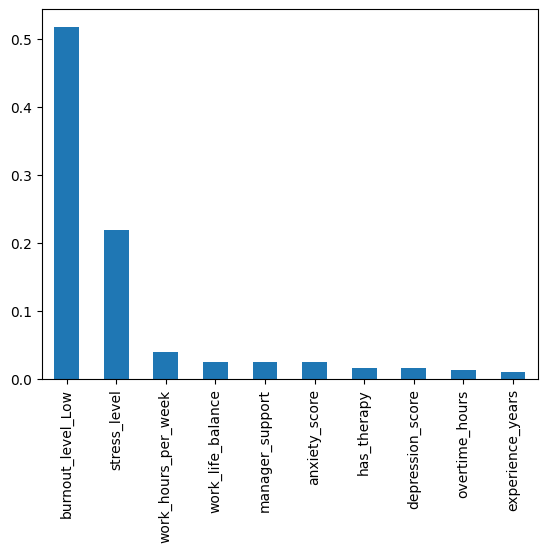

In [236]:
feature_imp.sort_values(ascending=False).head(10).plot(kind='bar')

In [55]:
# a model to predict burnout_level (Low/Moderate/High)?

In [56]:
df['burnout_level']

,burnout_level
0,Low
1,Moderate
2,Low
3,Moderate
4,Low
...,...
149995,Low
149996,Low
149997,Low
149998,Low


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [58]:
model=LogisticRegression()

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
x=df.drop(columns=['burnout_level'])

In [61]:
y=df['burnout_level']

In [62]:
cat_cols=x.select_dtypes(include='object').columns

In [63]:
num_cols=x.select_dtypes(include=np.number).columns

In [64]:
preprocess=ColumnTransformer(
    transformers=[('numeric',StandardScaler(),num_cols),
    ('categorical',OneHotEncoder(),cat_cols)]
)

In [65]:
pipeline=Pipeline(steps=[('preprocessing',preprocess),
               ('model',model)])

In [66]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [67]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  Index(['age', 'experience_years', 'work_hours_per_week', 'overtime_hours',
       'meetings_per_day', 'deadlines_missed', 'job_satisfaction',
       'manager_support', 'work_life_balance', 'sleep_hours',
       'physical_activity_days', 'screen_time_hours', 'caffeine_intake',
       'social_support_score', 'has_therapy', 'stress_level', 'anxiety_score',
       'depression_score', 'burnout_score', 'seeks_professional_help'],
      dtype='object')),
                                                 ('categorical',
                                                  OneHotEncoder(),
                                                  Index(['gender', 'job_role', 'company_size', 'work_mode'], dtype='object'))])),
                ('model', LogisticRegression())])

In [68]:
predictions=pipeline.predict(x_test)

In [69]:
from sklearn.metrics import accuracy_score

In [70]:
accuracy_score(y_test,predictions)

0.9997666666666667

In [71]:
pipeline.score(x_train,y_train)

0.999775

In [72]:
pipeline.score(x_test,y_test)

0.9997666666666667

In [73]:
from sklearn.model_selection import cross_val_score

In [74]:
np.mean(cross_val_score(pipeline,x,y,cv=5))

np.float64(0.9996666666666666)

In [75]:
y_shuffled = y.sample(frac=1, random_state=42)

pipeline.fit(x_train, y_shuffled.loc[x_train.index])
print(pipeline.score(x_test, y_test))

0.9997666666666667


In [76]:
#Is stress_level or anxiety_score more correlated with burnout?

In [77]:
df[['burnout_score','stress_level','anxiety_score']].corr().head(1)

,burnout_score,stress_level,anxiety_score
burnout_score,1.0,0.751516,0.548848


In [78]:
#What combination of factors leads to high burnout but high job satisfaction

In [79]:
df[(df['burnout_score']>df['burnout_score'].quantile(0.75)) & (df['job_satisfaction']>df['job_satisfaction'].quantile(0.75))]

,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
17,54,Female,Frontend Developer,8.4,Mid-size,Remote,53.0,6.0,1.0,0,...,8.5,4,4.1,0,5.9,5.7,2.2,3.4,Low,0
18,33,Male,Data Scientist,6.9,MNC,Hybrid,52.0,6.0,4.0,3,...,8.5,3,3.6,1,7.6,6.7,3.7,2.9,Low,0
23,37,Male,Software Engineer,3.7,Large,Remote,50.0,13.0,3.0,1,...,7.7,1,4.8,0,6.5,4.7,3.6,4.2,Moderate,1
24,36,Male,Software Engineer,6.2,Large,Hybrid,57.0,14.0,5.0,3,...,8.1,1,6.9,0,6.1,4.0,2.3,3.0,Low,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149910,31,Female,Frontend Developer,6.9,Large,Remote,40.0,1.0,5.0,1,...,7.1,5,7.0,1,7.4,4.8,3.0,3.0,Low,0
149938,45,Male,Frontend Developer,7.1,MNC,Remote,46.0,0.0,3.0,1,...,5.6,3,7.0,0,8.4,6.0,4.1,3.1,Low,0
149964,25,Female,Product Manager,3.1,Large,Hybrid,44.0,11.0,4.0,1,...,6.8,1,6.9,0,7.0,4.2,2.8,3.2,Low,0
149974,39,Female,Data Scientist,8.0,MNC,Hybrid,59.0,8.0,3.0,4,...,7.5,1,7.5,0,7.6,4.8,3.4,4.7,Moderate,1


In [80]:
df[(df['burnout_score']>df['burnout_score'].quantile(0.75)) & (df['job_satisfaction']>df['job_satisfaction'].quantile(0.75))].describe()

,age,experience_years,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,seeks_professional_help
count,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000,8149.000000
mean,37.924653,5.048767,51.901951,7.283593,3.985888,1.285434,8.066474,4.637796,3.660351,6.273273,2.476255,8.081568,2.107375,5.241281,0.146766,7.189888,5.433452,3.588624,3.686416,0.198061
std,9.454758,2.907628,7.196184,3.826753,2.008004,1.423559,0.862922,1.844355,1.640120,1.189089,1.800925,2.005184,1.303344,1.964841,0.353895,0.935884,1.043809,0.969757,0.688866,0.398563
min,22.000000,0.000000,30.000000,0.000000,0.000000,0.000000,7.000000,1.000000,1.000000,3.000000,0.000000,3.000000,0.000000,1.000000,0.000000,3.600000,1.000000,1.000000,2.900000,0.000000
25%,30.000000,2.900000,47.000000,5.000000,3.000000,0.000000,7.400000,3.300000,2.400000,5.500000,1.000000,6.700000,1.000000,3.900000,0.000000,6.500000,4.700000,2.900000,3.100000,0.000000
50%,38.000000,5.000000,52.000000,7.000000,4.000000,1.000000,7.900000,4.600000,3.600000,6.300000,2.000000,8.100000,2.000000,5.200000,0.000000,7.200000,5.400000,3.600000,3.500000,0.000000
75%,46.000000,7.000000,57.000000,10.000000,5.000000,2.000000,8.600000,5.900000,4.800000,7.100000,4.000000,9.500000,3.000000,6.600000,0.000000,7.800000,6.100000,4.200000,4.100000,0.000000
max,54.000000,17.100000,84.000000,24.000000,12.000000,5.000000,10.000000,10.000000,10.000000,10.000000,7.000000,15.500000,5.000000,10.000000,1.000000,10.000000,9.600000,7.100000,7.400000,1.000000


In [81]:
# correlation matrix of all numerical variables?

In [82]:
df.corr(numeric_only=True)

,age,experience_years,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,seeks_professional_help
age,1.000000,-0.001317,-0.002374,-0.001275,-0.000372,-0.001470,0.003923,0.002771,-0.002718,-0.001969,-0.001251,-0.001931,-0.001288,-0.000459,-0.001905,0.000281,0.000303,-0.001763,-0.001800,-0.001979
experience_years,-0.001317,1.000000,0.003697,0.000824,-0.002055,-0.001120,0.003895,0.001142,0.001237,0.002509,0.000958,0.000726,-0.002549,-0.001465,-0.000940,0.001188,0.000036,0.000532,-0.000691,0.001163
work_hours_per_week,-0.002374,0.003697,1.000000,-0.004648,0.001536,-0.000657,-0.006389,0.000711,-0.001110,0.003725,0.002098,0.000361,0.001278,-0.001807,-0.004120,0.293580,0.162561,0.173718,0.439901,0.094512
overtime_hours,-0.001275,0.000824,-0.004648,1.000000,-0.002192,-0.002617,-0.002267,0.004314,0.005116,0.000482,0.003044,0.001711,0.002156,0.001959,-0.002279,0.222274,0.121404,0.131802,0.218801,0.051139
meetings_per_day,-0.000372,-0.002055,0.001536,-0.002192,1.000000,-0.003956,0.000868,0.005928,-0.000771,-0.002543,-0.004900,0.000882,-0.000490,0.001781,-0.000764,0.001347,0.001316,0.001199,0.000182,-0.001649
deadlines_missed,-0.001470,-0.001120,-0.000657,-0.002617,-0.003956,1.000000,-0.004622,0.002509,0.001076,0.002955,-0.000508,-0.004575,0.000075,0.001050,0.001514,-0.003146,-0.000677,-0.000820,-0.002454,0.000165
job_satisfaction,0.003923,0.003895,-0.006389,-0.002267,0.000868,-0.004622,1.000000,0.002303,-0.001674,0.002212,-0.000261,-0.000351,-0.002873,-0.003742,-0.002694,-0.002801,0.000761,-0.314320,-0.038412,-0.006926
manager_support,0.002771,0.001142,0.000711,0.004314,0.005928,0.002509,0.002303,1.000000,0.003686,0.002266,-0.001425,0.000017,-0.000348,0.002821,0.001581,-0.295203,-0.166405,-0.174400,-0.318187,-0.073470
work_life_balance,-0.002718,0.001237,-0.001110,0.005116,-0.000771,0.001076,-0.001674,0.003686,1.000000,0.000628,-0.006805,-0.000989,-0.000253,-0.001383,0.000787,-0.585891,-0.318997,-0.340977,-0.497680,-0.115561
sleep_hours,-0.001969,0.002509,0.003725,0.000482,-0.002543,0.002955,0.002212,0.002266,0.000628,1.000000,-0.002416,0.002771,-0.000891,-0.003495,-0.002581,-0.267344,-0.143668,-0.347916,-0.133059,-0.037188


In [83]:
#Does sleep_hours negatively correlate with stress_level?

In [84]:
df['sleep_hours'].corr(df['stress_level'])

np.float64(-0.26734403476153346)

In [85]:
#Is screen_time_hours positively correlated with anxiety_score?

In [86]:
df['screen_time_hours'].corr(df['anxiety_score'])

np.float64(0.1705694764816776)

In [87]:
df.groupby(pd.qcut(df['screen_time_hours'],4,labels=['q1','q2','q3','q4']))['anxiety_score'].mean()

,anxiety_score
screen_time_hours,
q1,4.274553
q2,4.454309
q3,4.599338
q4,4.784121


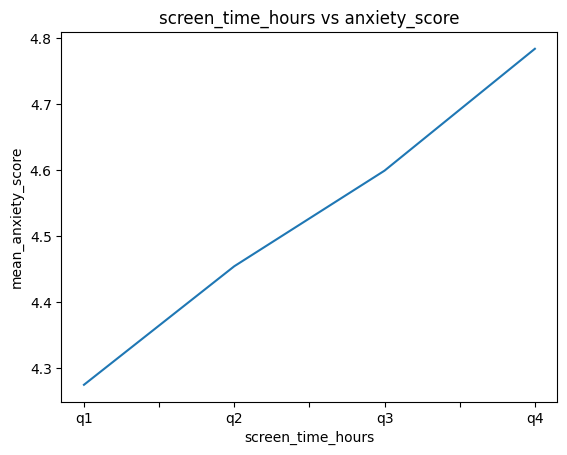

In [88]:
df.groupby(pd.qcut(df['screen_time_hours'],4,labels=['q1','q2','q3','q4']))['anxiety_score'].mean().plot()
plt.ylabel('mean_anxiety_score')
plt.title('screen_time_hours vs anxiety_score')
plt.show()

In [89]:
#Does physical_activity_days reduce depression?

In [90]:
df['physical_activity_days'].corr(df['depression_score'])

np.float64(-0.08322828272862312)

In [91]:
df.groupby('physical_activity_days')['depression_score'].mean()

,depression_score
physical_activity_days,
0,3.243129
1,3.168425
2,3.135129
3,3.074172
4,3.030593
5,2.953986
6,2.935922
7,2.824013


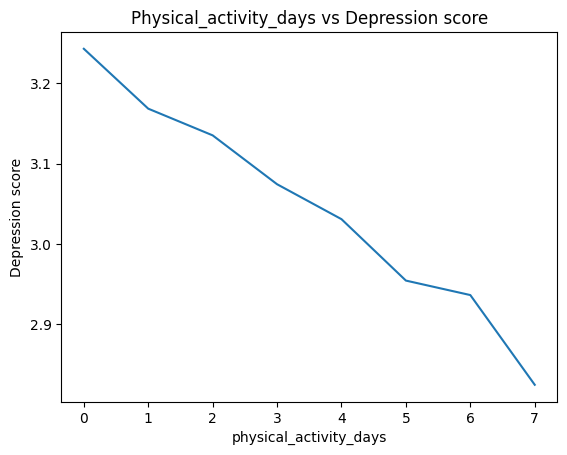

In [92]:
df.groupby('physical_activity_days')['depression_score'].mean().plot()
plt.ylabel('Depression score')
plt.title('Physical_activity_days vs Depression score')
plt.show()

In [93]:
#Which variable has the strongest inverse relationship with burnout?

In [94]:
df.corrwith(df['burnout_score'],numeric_only=True).sort_values(ascending=True).head(1)

,0
work_life_balance,-0.49768


In [95]:
#Does company_size impact burnout levels?

In [96]:
pivot=df.pivot_table(index='burnout_level',columns='company_size',values='burnout_score',aggfunc='count')

In [97]:
pivot

company_size,Large,MNC,Mid-size,Startup
burnout_level,,,,
High,16,19,15,15
Low,32928,32916,32760,33016
Moderate,4679,4526,4581,4529


<Axes: xlabel='burnout_level'>

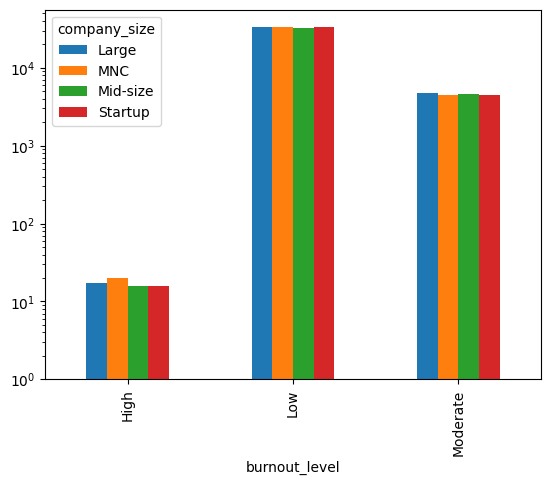

In [98]:
df.pivot_table(index='burnout_level',columns='company_size',values='burnout_score',aggfunc='count').plot(kind='bar',log=0.01)

In [99]:
pivot/pivot.sum(axis=0)*100

company_size,Large,MNC,Mid-size,Startup
burnout_level,,,,
High,0.042527,0.050719,0.040154,0.039936
Low,87.520931,87.867382,87.696756,87.902023
Moderate,12.436541,12.081899,12.263090,12.058040


In [100]:
#Are startup employees more stressed than MNC employees?

In [101]:
df[['company_size','stress_level']].groupby('company_size').mean()

,stress_level
company_size,
Large,5.791370
MNC,5.779742
Mid-size,5.783807
Startup,5.786760


In [102]:
high_stress=df[df['stress_level']>df['stress_level'].quantile(0.75)]

In [103]:
high_stress.groupby('company_size').size()

,0
company_size,
Large,8981
MNC,8723
Mid-size,8720
Startup,8948


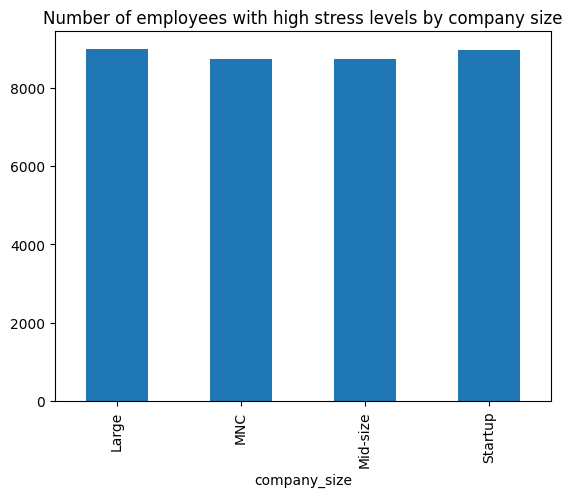

In [104]:
high_stress.groupby('company_size').size().plot(kind='bar')
plt.title('Number of employees with high stress levels by company size')
plt.show()

In [105]:
#Does work_mode (Remote/Hybrid/Onsite) influence work-life balance?

In [106]:
df.groupby('work_mode')['work_life_balance'].mean()

,work_life_balance
work_mode,
Hybrid,5.019119
Onsite,5.011125
Remote,5.016933


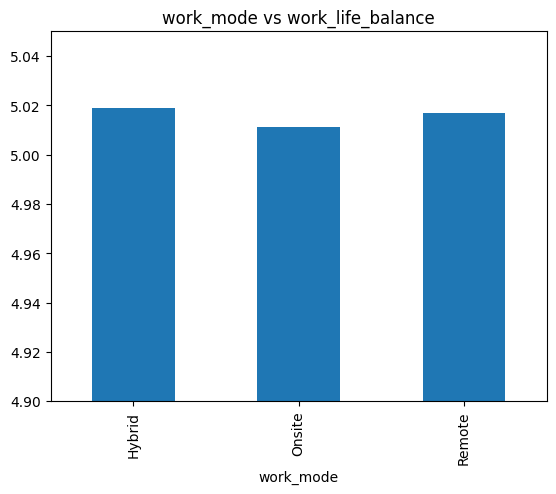

In [107]:
df.groupby('work_mode')['work_life_balance'].mean().plot(kind='bar',ylim=(4.9,5.05))
plt.title('work_mode vs work_life_balance')
plt.show()

In [108]:
#Which work mode results in the lowest burnout?

In [109]:
df[['work_mode','burnout_score']].groupby('work_mode').mean()

,burnout_score
work_mode,
Hybrid,2.113654
Onsite,2.117759
Remote,2.112058


In [110]:
#Do remote workers have higher screen time but lower stress?

In [111]:
new=df[(df['screen_time_hours']>df['screen_time_hours'].mean()) & (df['stress_level']<df['stress_level'].mean())]
new['work_mode'].value_counts()

,count
work_mode,
Hybrid,14420
Remote,12612
Onsite,8896


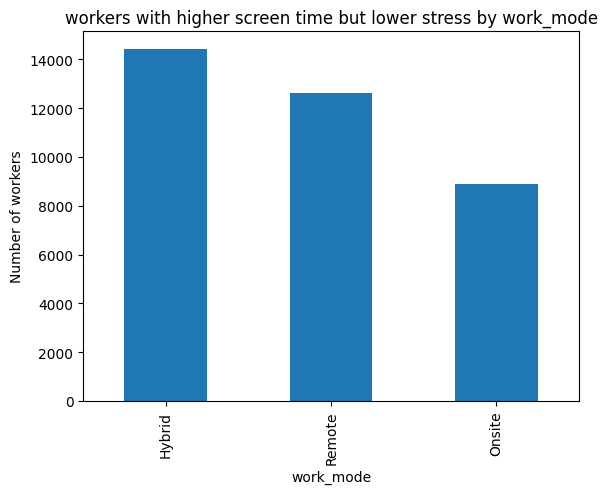

In [112]:
new['work_mode'].value_counts().plot(kind='bar')
plt.title('workers with higher screen time but lower stress by work_mode')
plt.ylabel('Number of workers')
plt.show()

In [113]:
df['high_screen_low_stress'] = (
    (df['screen_time_hours'] > df['screen_time_hours'].mean()) &
    (df['stress_level'] < df['stress_level'].mean())
)

In [114]:
df.groupby('work_mode')['high_screen_low_stress'].mean() * 100

,high_screen_low_stress
work_mode,
Hybrid,24.010923
Onsite,23.739759
Remote,24.036134


In [115]:
#Which job role has the highest average burnout?

In [116]:
a=df.groupby('job_role')['burnout_score'].mean().sort_values(ascending=False).head(1)

for i,val in a.items():
    print(f'job role with highest average burnout is {i} {val}')

job role with highest average burnout is Frontend Developer 2.1267824344631827


In [117]:
#Are Data Scientists more satisfied than Developers?

In [118]:
df1=df[(df['job_role']=='Data Scientist') | (df['job_role']=='Backend Developer') | (df['job_role']=='Frontend Developer')]

In [119]:
df1['job_role']=df1['job_role'].replace({'Backend Developer':'Developers','Frontend Developer':'Developers'})

In [120]:
df1.groupby('job_role')['job_satisfaction'].mean()

,job_satisfaction
job_role,
Data Scientist,5.507918
Developers,5.501379


In [121]:
#Which role has the worst work-life balance?

In [122]:
df.groupby('job_role')['work_life_balance'].mean().sort_values(ascending=True)

,work_life_balance
job_role,
Product Manager,4.997602
Software Engineer,5.008399
Frontend Developer,5.017181
Data Scientist,5.018100
DevOps,5.018500
ML Engineer,5.019534
Backend Developer,5.026738
QA Engineer,5.037884


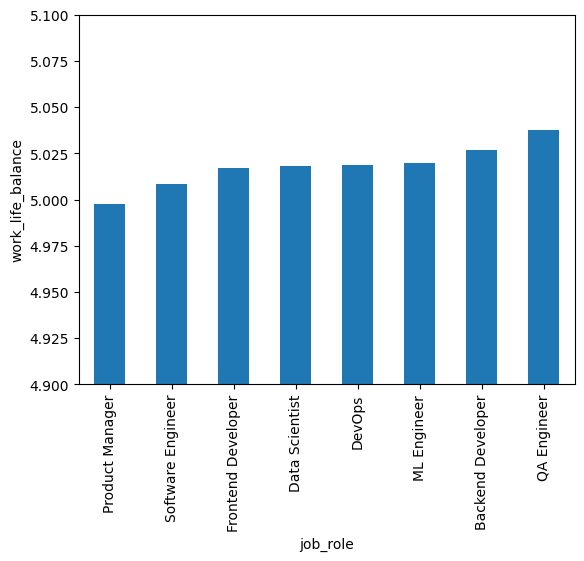

In [123]:
df.groupby('job_role')['work_life_balance'].mean().sort_values(ascending=True).plot(kind='bar',ylim=(4.9,5.1))
plt.ylabel('work_life_balance')
plt.show()

In [124]:
#Do DevOps engineers experience more overtime than others?

In [125]:
df.groupby('job_role')['overtime_hours'].mean()

,overtime_hours
job_role,
Backend Developer,6.158139
Data Scientist,6.140362
DevOps,6.095321
Frontend Developer,6.134803
ML Engineer,6.110615
Product Manager,6.105577
QA Engineer,6.094570
Software Engineer,6.135981


In [126]:
df['job_role'].unique()

array(['Backend Developer', 'Frontend Developer', 'DevOps',
       'Data Scientist', 'Software Engineer', 'Product Manager',
       'QA Engineer', 'ML Engineer'], dtype=object)

In [127]:
df1=df.copy()

In [128]:
roles=['Backend Developer', 'Frontend Developer','Data Scientist', 'Software Engineer', 'Product Manager',
       'QA Engineer', 'ML Engineer']

In [129]:
for i in df1['job_role'].unique():
    if i in roles:
        df1['job_role']=df1['job_role'].replace({i:'Others'})



In [130]:
df['job_role'].where(df['job_role']=='DevOps','Others')

,job_role
0,Others
1,Others
2,DevOps
3,Others
4,Others
...,...
149995,DevOps
149996,Others
149997,Others
149998,Others


In [131]:
df1.groupby('job_role')['overtime_hours'].mean()

,overtime_hours
job_role,
DevOps,6.095321
Others,6.130693


<Axes: xlabel='job_role'>

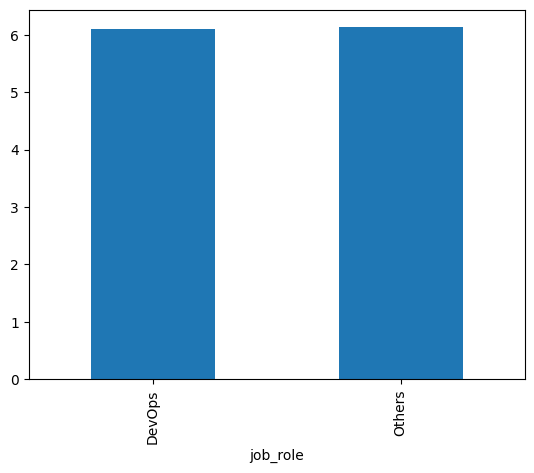

In [132]:
df1.groupby('job_role')['overtime_hours'].mean().plot(kind='bar')

In [133]:
#Is experience affecting stress differently across roles?

In [134]:
for i in df['job_role'].unique():
    new=df[df['job_role']==i]
    corr=round(new['experience_years'].corr(new['stress_level']),6)
    print(f'role:{i},corr:{corr}')


role:Backend Developer,corr:-0.007143
role:Frontend Developer,corr:-0.00428
role:DevOps,corr:-0.003594
role:Data Scientist,corr:0.003664
role:Software Engineer,corr:0.007626
role:Product Manager,corr:0.013059
role:QA Engineer,corr:0.005567
role:ML Engineer,corr:-0.007154


In [135]:
#Does experience_years reduce stress or increase burnout?

In [136]:
df[['stress_level','burnout_score']].corrwith(df['experience_years'])

,0
stress_level,0.001188
burnout_score,-0.000691


In [137]:
#Are junior employees more anxious than senior ones?

In [138]:
df['experience_years'].describe()

,experience_years
count,150000.000000
mean,5.055010
std,2.878602
min,0.000000
25%,3.000000
50%,5.000000
75%,7.000000
max,18.500000


In [139]:
df['position']=np.where(df['experience_years']>3,'Senior','Junior')

In [140]:
df.groupby('position')['anxiety_score'].mean()

,anxiety_score
position,
Junior,4.524689
Senior,4.523439


<Axes: xlabel='position'>

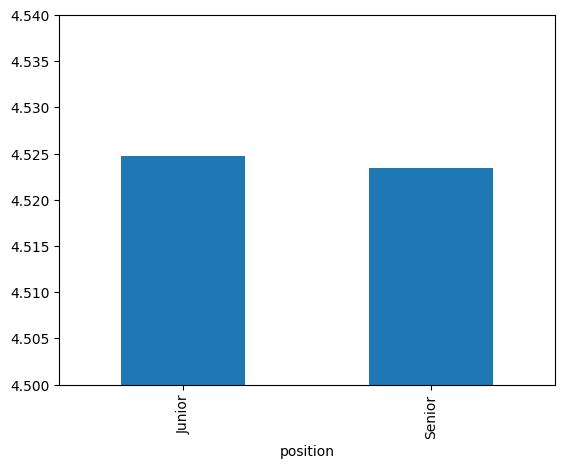

In [141]:
df.groupby('position')['anxiety_score'].mean().plot(kind='bar',ylim=(4.5,4.54))

In [142]:
# high anxiety

In [143]:
high_anxiety=df[df['anxiety_score']>df['anxiety_score'].quantile(0.75)]

In [144]:
high_anxiety.groupby('position')['anxiety_score'].mean()

,anxiety_score
position,
Junior,6.067242
Senior,6.062280


In [145]:
from scipy.stats import ttest_ind

In [146]:
junior=df.loc[df['position']=='Junior']['anxiety_score']

In [147]:
senior=df.loc[df['position']=='Senior']['anxiety_score']

In [148]:
ttest_ind(junior,senior)

TtestResult(statistic=np.float64(0.17672476072034635), pvalue=np.float64(0.8597248293465808), df=np.float64(149998.0))

In [149]:
#Does job satisfaction increase linearly with experience?

In [150]:
df['experience_years'].corr(df['job_satisfaction'])

np.float64(0.0038953058809000937)

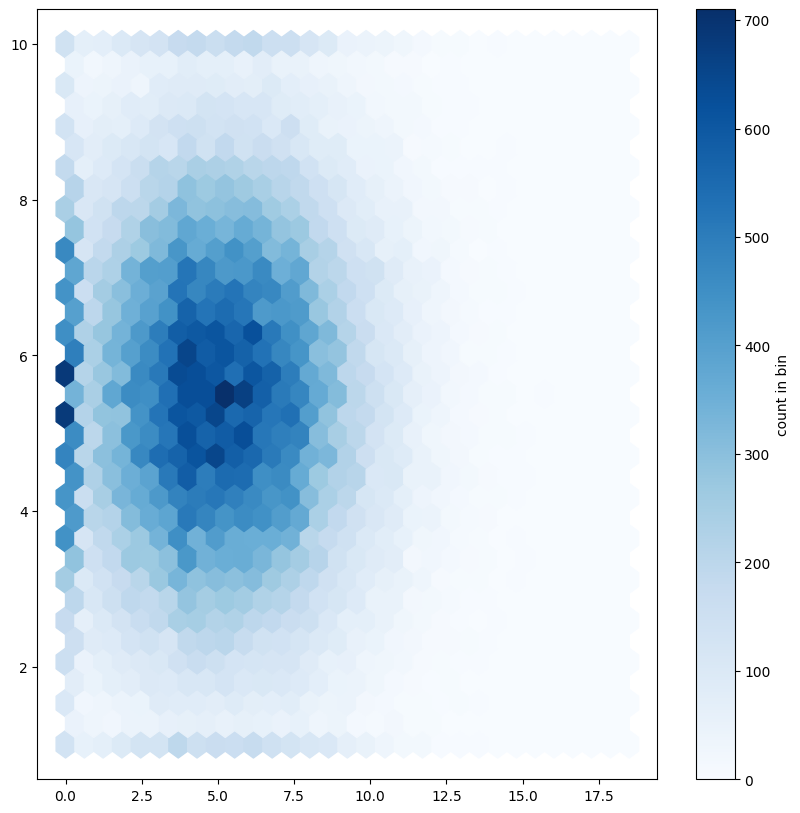

In [151]:
plt.figure(figsize=(10,10))
plt.hexbin(df['experience_years'],df['job_satisfaction'],gridsize=30,cmap='Blues')
plt.colorbar(label='count in bin')

In [152]:
df['experience_level']=pd.cut(df['experience_years'],bins=[0,2,5,10,18],labels=['0-2','3-5','6-10','11-18'])

In [153]:
df.groupby('experience_level')['job_satisfaction'].mean()

,job_satisfaction
experience_level,
0-2,5.489798
3-5,5.493542
6-10,5.508776
11-18,5.525555


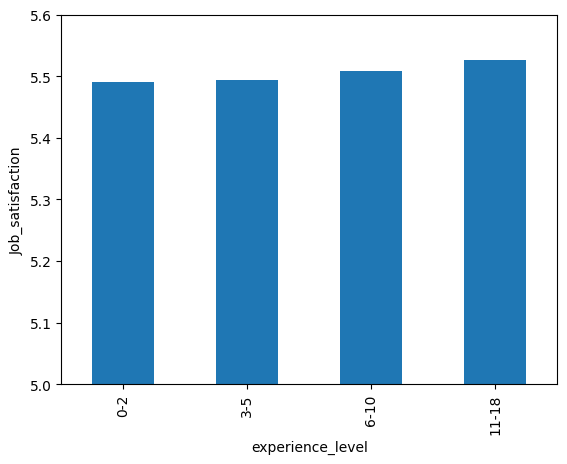

In [154]:
df.groupby('experience_level')['job_satisfaction'].mean().plot(kind='bar',ylim=(5,5.6))
plt.ylabel('Job_satisfaction')
plt.show()

In [155]:
# checking linearity

In [156]:
from sklearn.linear_model import LinearRegression

In [157]:
lr=LinearRegression()

In [158]:
x=df[['experience_years']]
y=df['job_satisfaction']

In [159]:
lr.fit(x,y)

LinearRegression()

In [160]:
pred_x=lr.predict(x)

In [161]:
residuals=y-pred_x

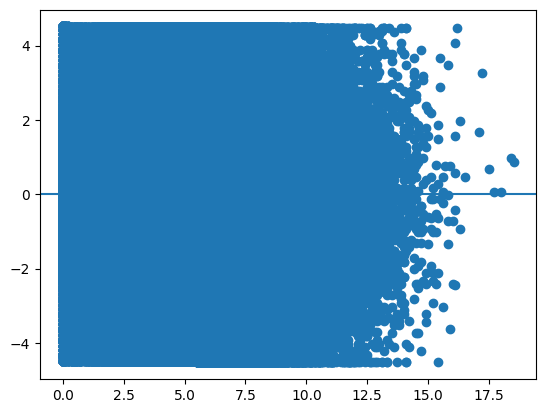

In [162]:
plt.scatter(df['experience_years'],residuals)
plt.axhline(y=0)

In [163]:
#How does experience interact with manager support?

In [164]:
df.groupby('experience_level')['manager_support'].mean()

,manager_support
experience_level,
0-2,5.487274
3-5,5.488582
6-10,5.504478
11-18,5.489484


In [165]:
df['manager_support'].corr(df['experience_years'])

np.float64(0.0011424961566628426)

In [166]:
#Does social_support_score reduce depression and anxiety?

In [167]:
df[['anxiety_score','depression_score']].corrwith(df['social_support_score'])

,0
anxiety_score,-0.489403
depression_score,-0.139990


In [168]:
df['social_support']=pd.qcut(df['social_support_score'],3,labels=['low','medium','high'])

In [169]:
df.groupby('social_support')[['anxiety_score','depression_score']].mean()

,anxiety_score,depression_score
social_support,,
low,5.165976,3.277851
medium,4.512677,3.096922
high,3.854064,2.904088


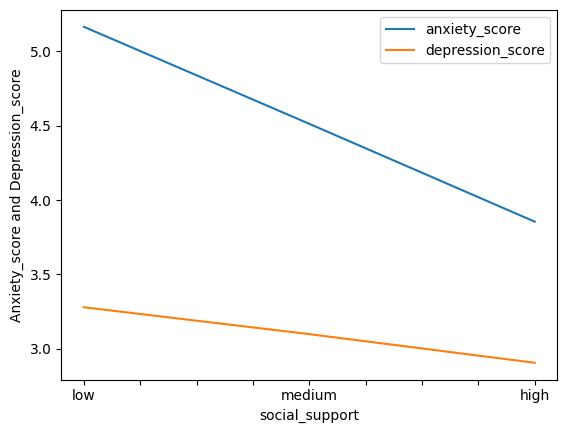

In [170]:
df.groupby('social_support')[['anxiety_score','depression_score']].mean().plot()
plt.ylabel('Anxiety_score and Depression_score')
plt.show()

In [171]:
#Is manager_support strongly linked to job satisfaction?

In [172]:
df['manager_support'].corr(df['job_satisfaction'])

np.float64(0.002303494262544756)

In [173]:
df['ms']=pd.qcut(df['manager_support'],3,labels=['low','medium','high'])

In [174]:
df.groupby('ms')['job_satisfaction'].mean()

,job_satisfaction
ms,
low,5.488863
medium,5.508829
high,5.502906


<Axes: xlabel='ms'>

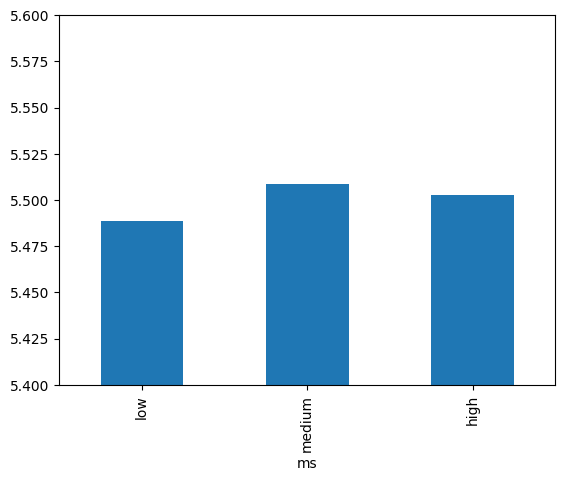

In [175]:
df.groupby('ms')['job_satisfaction'].mean().plot(kind='bar',ylim=(5.4,5.6))

In [176]:
df.groupby(['experience_level','ms'])['job_satisfaction'].mean()

experience_level  ms    
0-2               low       5.485616
                  medium    5.538753
                  high      5.440665
3-5               low       5.474771
                  medium    5.503881
                  high      5.502416
6-10              low       5.500725
                  medium    5.504762
                  high      5.521527
11-18             low       5.529012
                  medium    5.527942
                  high      5.519172
Name: job_satisfaction, dtype: float64

In [177]:
z=df.groupby(['experience_level','ms'])['job_satisfaction'].mean().reset_index()

In [178]:
z

,experience_level,ms,job_satisfaction
0,0-2,low,5.485616
1,0-2,medium,5.538753
2,0-2,high,5.440665
3,3-5,low,5.474771
4,3-5,medium,5.503881
5,3-5,high,5.502416
6,6-10,low,5.500725
7,6-10,medium,5.504762
8,6-10,high,5.521527
9,11-18,low,5.529012


<Axes: xlabel='experience_level'>

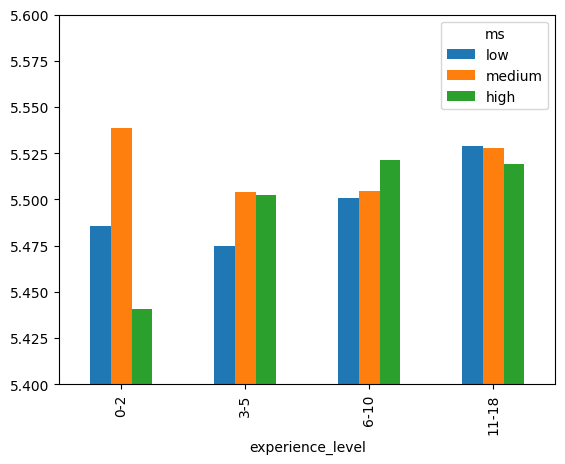

In [179]:
z.pivot(index='experience_level',columns='ms',values='job_satisfaction').plot(kind='bar',ylim=(5.4,5.6))

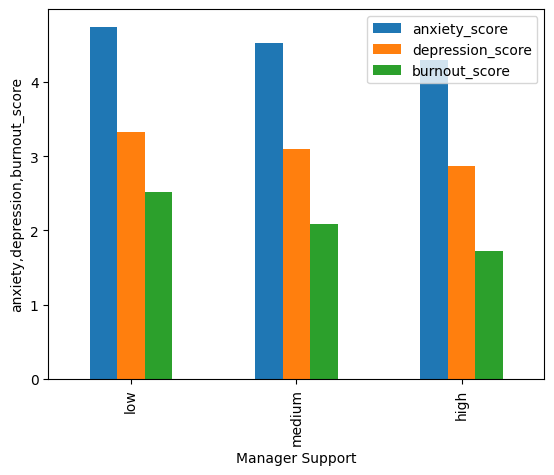

In [180]:
df.groupby('ms')[['anxiety_score','depression_score', 'burnout_score']].mean().plot(kind='bar')
plt.xlabel('Manager Support')
plt.ylabel('anxiety,depression,burnout_score')
plt.show()

df[['ms','anxiety_score']].groupby('ms').mean()

In [181]:
#Do employees with therapy have lower burnout?

In [182]:
df.groupby('has_therapy')['burnout_score'].mean()

,burnout_score
has_therapy,
0,2.224301
1,1.785572


<Axes: xlabel='has_therapy'>

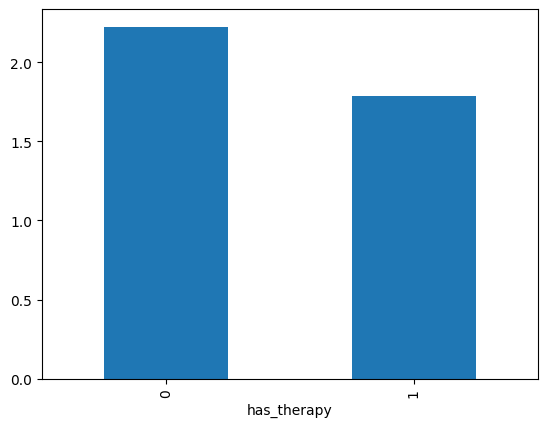

In [183]:
df.groupby('has_therapy')['burnout_score'].mean().plot(kind='bar')

In [184]:
df.groupby(['has_therapy','experience_level']).agg({'burnout_score':'mean'}).reset_index()

,has_therapy,experience_level,burnout_score
0,0,0-2,2.249505
1,0,3-5,2.219156
2,0,6-10,2.221116
3,0,11-18,2.232712
4,1,0-2,1.749812
5,1,3-5,1.783533
6,1,6-10,1.792338
7,1,11-18,1.788634


In [185]:
a=df.groupby(['has_therapy','experience_level']).agg({'burnout_score':'mean'}).reset_index()

In [186]:
a.pivot_table(index='has_therapy',columns='experience_level',values='burnout_score',aggfunc='mean')

experience_level,0-2,3-5,6-10,11-18
has_therapy,,,,
0,2.249505,2.219156,2.221116,2.232712
1,1.749812,1.783533,1.792338,1.788634


<Axes: xlabel='has_therapy'>

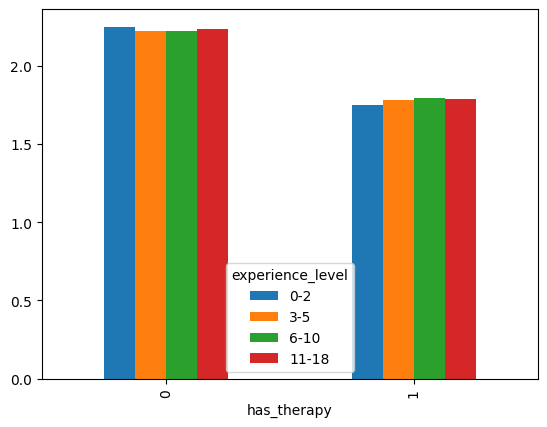

In [187]:
a.pivot_table(index='has_therapy',columns='experience_level',values='burnout_score',aggfunc='mean').plot(kind='bar')

Statistics test

In [188]:
from scipy.stats import ttest_ind

In [189]:
no_therapy=df.loc[df['has_therapy']==0]['burnout_score']
therapy=df.loc[df['has_therapy']==1]['burnout_score']

In [190]:
ttest_ind(no_therapy,therapy)

TtestResult(statistic=np.float64(67.21944233688849), pvalue=np.float64(0.0), df=np.float64(149998.0))

In [191]:
#Which factor matters more: manager support or social support?

In [192]:
b=df.copy()

In [193]:
b['manager_support_level']=pd.qcut(b['manager_support'],3,labels=['low','medium','high'])

In [194]:
b['social_support_level']=pd.qcut(b['social_support_score'],3,labels=['low','medium','high'])

In [195]:
b.groupby('manager_support_level')[['stress_level', 'anxiety_score','depression_score', 'burnout_score']].mean()

,stress_level,anxiety_score,depression_score,burnout_score
manager_support_level,,,,
low,6.217957,4.743947,3.324721,2.517015
medium,5.779468,4.520155,3.091438,2.081840
high,5.335237,4.295214,2.861639,1.723943


In [196]:
b.groupby('social_support_level')[['stress_level', 'anxiety_score','depression_score', 'burnout_score']].mean()

,stress_level,anxiety_score,depression_score,burnout_score
social_support_level,,,,
low,5.781803,5.165976,3.277851,2.231947
medium,5.784287,4.512677,3.096922,2.109290
high,5.790525,3.854064,2.904088,1.994315


In [197]:
df[['stress_level', 'anxiety_score','depression_score', 'burnout_score']].corrwith(df['manager_support'])

,0
stress_level,-0.295203
anxiety_score,-0.166405
depression_score,-0.174400
burnout_score,-0.318187


In [198]:
df[['stress_level', 'anxiety_score','depression_score', 'burnout_score']].corrwith(df['social_support_score'])

,0
stress_level,0.003281
anxiety_score,-0.489403
depression_score,-0.139990
burnout_score,-0.095010


In [199]:
import statsmodels.api as sm

In [200]:
x=df[['manager_support','social_support_score']]
y=df['job_satisfaction']

In [201]:
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       job_satisfaction   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.452
Date:                Tue, 05 May 2026   Prob (F-statistic):              0.234
Time:                        16:28:02   Log-Likelihood:            -3.1348e+05
No. Observations:              150000   AIC:                         6.270e+05
Df Residuals:                  149997   BIC:                         6.270e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.5081 

In [202]:
#Does sleep_hours significantly reduce stress and burnout?

In [203]:
df[['stress_level','burnout_score']].corrwith(df['sleep_hours'])

,0
stress_level,-0.267344
burnout_score,-0.133059


In [204]:
b['sleep_level']=pd.qcut(b['sleep_hours'],3,labels=['low','medium','high'])

In [205]:
b.groupby('sleep_level')[['stress_level','burnout_score']].mean()

,stress_level,burnout_score
sleep_level,,
low,6.159826,2.271812
medium,5.771042,2.104294
high,5.387481,1.950290


<Axes: xlabel='sleep_level'>

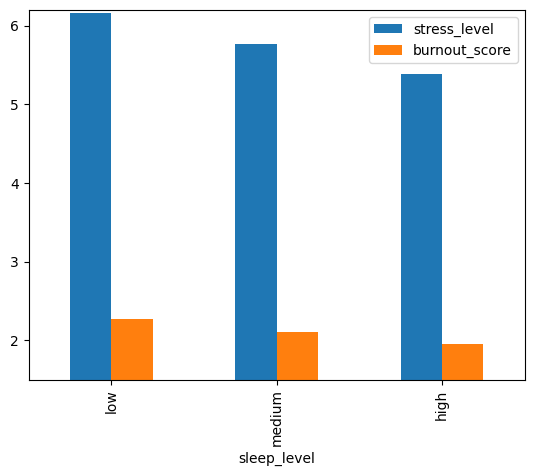

In [206]:
b.groupby('sleep_level')[['stress_level','burnout_score']].mean().plot(kind='bar',ylim=(1.5,6.2))

In [207]:
b.groupby('sleep_level')[['stress_level','burnout_score']].describe()

stress_level                                                \
                   count      mean       std  min  25%  50%  75%   max   
sleep_level                                                              
low              53229.0  6.159826  1.297694  1.1  5.3  6.2  7.0  10.0   
medium           48443.0  5.771042  1.287711  1.0  4.9  5.8  6.6  10.0   
high             48328.0  5.387481  1.293410  1.0  4.5  5.4  6.3  10.0   

            burnout_score                                               
                    count      mean       std  min  25%  50%  75%  max  
sleep_level                                                             
low               53229.0  2.271812  1.160702  1.0  1.1  2.1  3.1  8.1  
medium            48443.0  2.104294  1.103676  1.0  1.0  1.9  2.8  7.2  
high              48328.0  1.950290  1.040711  1.0  1.0  1.6  2.6  7.1

Statistics test

In [208]:
from scipy.stats import f_oneway

In [209]:
f_oneway(b[b['sleep_level']=='low']['stress_level'],
         b[b['sleep_level']=='medium']['stress_level'],
         b[b['sleep_level']=='high']['stress_level'])

F_onewayResult(statistic=np.float64(4522.657830693469), pvalue=np.float64(0.0))

In [210]:
#Is caffeine intake increasing anxiety?

In [211]:
df['caffeine_intake'].corr(df['anxiety_score'])

np.float64(0.0022630436158687147)

In [212]:
#Do physically active employees have lower depression scores?

In [213]:
b['physical_activity_days'].corr(b['depression_score'])

np.float64(-0.08322828272862312)

<Axes: xlabel='physical_activity_days'>

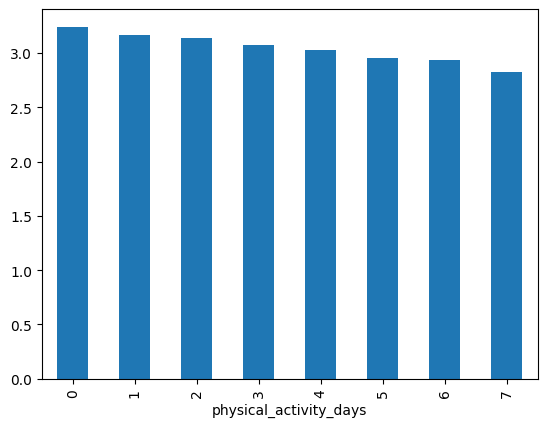

In [214]:
b.groupby('physical_activity_days')['depression_score'].mean().plot(kind='bar')

In [215]:
b.groupby('physical_activity_days')[['depression_score','stress_level', 'anxiety_score','burnout_score']].mean()

,depression_score,stress_level,anxiety_score,burnout_score
physical_activity_days,,,,
0,3.243129,5.786040,5.041014,2.207788
1,3.168425,5.753893,4.837579,2.152518
2,3.135129,5.778999,4.641251,2.135449
3,3.074172,5.796391,4.447559,2.100708
4,3.030593,5.803702,4.251953,2.074929
5,2.953986,5.782211,4.040374,2.026571
6,2.935922,5.804517,3.853841,2.012199
7,2.824013,5.802234,3.633108,1.966351


In [216]:
#Is screen time negatively impacting sleep?

In [217]:
df['screen_time_hours'].corr(df['sleep_hours'])

np.float64(0.0027709992808276273)

In [218]:
b['screen_time_level']=pd.qcut(b['screen_time_hours'],3,labels=['low','medium','high'])

In [219]:
b.groupby('screen_time_level')['sleep_hours'].mean()

,sleep_hours
screen_time_level,
low,6.493678
medium,6.503545
high,6.500004


In [220]:
b.groupby('screen_time_level')[['sleep_hours','stress_level', 'anxiety_score','depression_score', 'burnout_score']].mean()

,sleep_hours,stress_level,anxiety_score,depression_score,burnout_score
screen_time_level,,,,,
low,6.493678,5.777527,4.299608,3.030408,2.071369
medium,6.503545,5.792871,4.528344,3.100490,2.117610
high,6.500004,5.785592,4.755445,3.162500,2.155435


In [221]:
b.groupby('screen_time_level')['sleep_hours'].describe()

,count,mean,std,min,25%,50%,75%,max
screen_time_level,,,,,,,,
low,50208.0,6.493678,1.194734,3.0,5.7,6.5,7.3,10.0
medium,52248.0,6.503545,1.188416,3.0,5.7,6.5,7.3,10.0
high,47544.0,6.500004,1.194126,3.0,5.7,6.5,7.3,10.0


In [222]:
#Can lifestyle variables alone predict burnout?

In [223]:
x=df[['sleep_hours',
'physical_activity_days',
'screen_time_hours',
'caffeine_intake',
'social_support_score',
'has_therapy',
'seeks_professional_help']]

In [224]:
y=df['burnout_score']

In [225]:
from sklearn.linear_model import LinearRegression

In [226]:
lr=LinearRegression()

In [227]:
from sklearn.preprocessing import StandardScaler

In [228]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [229]:
from sklearn.model_selection import train_test_split

In [230]:
standardize=ColumnTransformer(
    transformers=[('x_scaled',StandardScaler(),x.columns)]
)

In [231]:
pipeline=Pipeline(steps=[('standardize',standardize),
                ('lr',lr)])

In [232]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [233]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('standardize',
                 ColumnTransformer(transformers=[('x_scaled', StandardScaler(),
                                                  Index(['sleep_hours', 'physical_activity_days', 'screen_time_hours',
       'caffeine_intake', 'social_support_score', 'has_therapy',
       'seeks_professional_help'],
      dtype='object'))])),
                ('lr', LinearRegression())])

In [234]:
lifestyle_predictores=pipeline.predict(x_test)

In [235]:
r2_score(y_test,lifestyle_predictores)

0.10981255780845434